# Splice site evaluation over a BED file

Runs splice-site classification predictions over all (or a subset of) windows
defined by a BED file and aggregates AUPRC, confusion counts, and PR curves
across the full set.

## Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
species      = "Homo_sapiens"
if species   == "Mus_musculus":
    genome   = f"/home/elek/sds/sd17d003/Anamaria/genomes/mazin/fasta/{species}.fa"
elif species == "Homo_sapiens":
    genome   = f"/home/elek/sds/sd17d003/Anamaria/genomes/ensembl115/fasta/{species}.fa"
bed_file     = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/{species}/folds_100kb/FOLD_0_subset/test.bed"
annotation   = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/{species}/splice_sites.parquet"
usage_file   = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/{species}/usage.parquet"
checkpoint   = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_mouse_lora/best_model.pth"

# ── Settings ────────────────────────────────────────────────────────────────
device      = "cuda"
organism    = 0          # 0 = human, 1 = mouse
seq_len     = 131072
max_windows = 100         # set to None to run all windows in the BED file

# ── Labels / colours (shared across cells) ─────────────────────────────────
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS   = 4
CLASS_LABELS  = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}
TISSUE_COLORS = {
    'Brain': '#3399cc',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

## Load model and annotations

In [3]:
import numpy as np
import pandas as pd
import torch
import sys
from pathlib import Path

# Add scripts directory to Python path
# Navigate from notebook location to project root, then to scripts
notebook_dir = Path().absolute()
# Go up from notebooks/ to examples/, then to project root
project_root = notebook_dir
while project_root.name and project_root.name not in ["alphagenome_ft_pytorch", ""]:
    project_root = project_root.parent
    if project_root == project_root.parent:  # reached filesystem root
        project_root = Path("/home/elek/projects/alphagenome_ft_pytorch")
        break

scripts_dir = project_root / "scripts"
sys.path.insert(0, str(scripts_dir))

# Import model loading functions from evaluate_splice.py
from evaluate_splice import (
    resolve_checkpoint, load_config, build_model, build_usage_heads
)

# Load checkpoint and config using script functions
pth_path, cfg_path = resolve_checkpoint(checkpoint)
cfg = load_config(cfg_path)
ckpt = torch.load(pth_path, map_location=device, weights_only=False)

# Build model using script function (handles LoRA, heads, etc.)
model = build_model(cfg, ckpt, torch.device(device))

# Extract usage_heads dict from model for backward compatibility
if model.splice_sites_usage_head is not None:
    usage_heads = {int(k): v for k, v in model.splice_sites_usage_head.items()}
else:
    usage_heads = {}

print(f"Model loaded from: {checkpoint}")
print(f"Config mode: {cfg.get('mode', 'N/A')}")
print(f"Usage heads: {list(usage_heads.keys())}")

Building model (mode=lora, dtype=bfloat16, num_organisms=1)...
  Applying LoRA: rank=8, alpha=16, targets=['q_proj', 'v_proj']
  Loaded model_state_dict (epoch 20)
Model loaded from: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_mouse_lora/best_model.pth
Config mode: lora
Usage heads: [0]


In [4]:
model

AlphaGenome(
  (encoder): SequenceEncoder(
    (dna_embedder): DnaEmbedder(
      (conv1): Conv1d(4, 768, kernel_size=(15,), stride=(1,), padding=same)
      (block): ConvBlock(
        (norm): RMSBatchNorm()
        (conv): StandardizedConv1d(768, 768, kernel_size=(5,), stride=(1,))
      )
    )
    (pool): Pool1d()
    (down_blocks): ModuleList(
      (0): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(768, 896, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 896, kernel_size=(5,), stride=(1,))
        )
      )
      (1): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 1024, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(1024, 1024, kernel_size=(5,), stride=(1,)

In [5]:
import pyfaidx
from alphagenome_pytorch.utils.sequence import sequence_to_onehot

fasta   = pyfaidx.Fasta(genome, as_raw=True, sequence_always_upper=True)
annot   = pd.read_parquet(annotation)
usage   = pd.read_parquet(usage_file)
annot["Chromosome"] = annot["Chromosome"].astype(str)
usage["Chromosome"] = usage["Chromosome"].astype(str)

# Read BED windows
half = seq_len // 2
windows = []
with open(bed_file) as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        parts = line.strip().split()
        chrom  = parts[0]
        center = (int(parts[1]) + int(parts[2])) // 2
        windows.append((chrom, center - half, center + half))

if max_windows is not None:
    windows = windows[:max_windows]

print(f"Loaded {len(windows)} windows from {bed_file}")

Loaded 100 windows from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/folds_100kb/FOLD_0_subset/test.bed


## Run inference

Run inference for all sequences, using `collect_predictions()` from evaluate_splice.py for consistent inference.

In [6]:
from sklearn.metrics import average_precision_score, precision_recall_curve
from alphagenome_pytorch.utils.sequence import sequence_to_onehot
from alphagenome_pytorch.extensions.finetuning.splice_datasets import collate_splice
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader

# Label mapping: SiteType string → class index
label_to_idx = {name: i for i, name in enumerate(SPLICE_CLASS_NAMES)}
n_classes = len(SPLICE_CLASS_NAMES) + 1  # 4 splice + 1 background

# Simple dataset wrapper for BED windows with splice site annotations
class BEDSpliceDataset(Dataset):
    def __init__(self, windows, fasta, annot, usage, label_to_idx, seq_len, organism_idx, n_conditions=None, min_coverage=10, max_sites=1024):
        self.windows = windows
        self.fasta = fasta
        self.annot = annot
        self.usage = usage
        self.label_to_idx = label_to_idx
        self.seq_len = seq_len
        self.organism_idx = organism_idx
        self.n_conditions = n_conditions
        self.min_coverage = min_coverage
        self.max_sites = max_sites
        
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        chrom_w, start_w, end_w = self.windows[idx]
        
        # Extract sequence
        try:
            seq = self.fasta[chrom_w][start_w:end_w]
        except Exception:
            seq = "N" * self.seq_len
        
        if len(seq) != self.seq_len:
            seq = seq + "N" * (self.seq_len - len(seq))
        
        seq_onehot = sequence_to_onehot(seq).astype(np.float32)
        
        # Build ground-truth labels
        chrom_str = str(chrom_w)
        w_annot = self.annot[
            (self.annot["Chromosome"] == chrom_str) &
            (self.annot["Position"] >= start_w) &
            (self.annot["Position"] < end_w)
        ]
        
        cls_labels = np.full(self.seq_len, BACKGROUND_CLASS, dtype=np.int64)
        for _, row in w_annot.iterrows():
            rel_pos = int(row["Position"]) - start_w
            if 0 <= rel_pos < self.seq_len:
                cls_labels[rel_pos] = self.label_to_idx.get(row["SiteType"], BACKGROUND_CLASS)
        
        result = {
            "sequence": torch.from_numpy(seq_onehot),
            "organism_index": torch.tensor(self.organism_idx, dtype=torch.long),
            "classification_labels": torch.from_numpy(cls_labels),
        }
        
        # Add usage data if n_conditions is specified (pre-padded to max_sites)
        if self.n_conditions is not None and self.n_conditions > 0:
            # Get ALL usage sites in this window (no annotation or coverage filter)
            # Evaluate all sites that appear in usage.parquet
            w_usage = self.usage[
                (self.usage["Chromosome"] == chrom_str) &
                (self.usage["Position"] >= start_w) &
                (self.usage["Position"] < end_w)
            ]
            
            # Build position-indexed usage data
            usage_by_pos = {}  # {rel_pos: {cond_idx: sse_value}}
            for _, row in w_usage.iterrows():
                rel_pos = int(row["Position"]) - start_w
                if 0 <= rel_pos < self.seq_len:
                    if rel_pos not in usage_by_pos:
                        usage_by_pos[rel_pos] = {}
                    cond_idx = int(row["Condition"])
                    if cond_idx < self.n_conditions:
                        usage_by_pos[rel_pos][cond_idx] = float(row["SSE"])
            
            # Convert to arrays, pre-padded to max_sites (matches SpliceSiteDataset behavior)
            n_sites = len(usage_by_pos)
            n_pad = self.max_sites - min(n_sites, self.max_sites)
            
            # Trim to max_sites if needed
            site_items = sorted(usage_by_pos.items())[:self.max_sites]
            
            # Build position array
            positions = np.array([pos for pos, _ in site_items], dtype=np.int64)
            if n_pad > 0:
                positions = np.concatenate([positions, np.full(n_pad, -1, dtype=np.int64)])
            
            # Build values and mask arrays
            # For each site, evaluate ALL conditions:
            # - Observed conditions: ground truth = SSE value
            # - Unobserved conditions: ground truth = 0 (site not used in that condition)
            # - Mask = True for all conditions
            if site_items:
                values_list = []
                mask_list = []
                for _, cond_dict in site_items:
                    vals = np.zeros(self.n_conditions, dtype=np.float32)
                    mask = np.ones(self.n_conditions, dtype=bool)  # Evaluate all conditions
                    # Fill in observed SSE values (unobserved remain 0)
                    for cond_idx, sse_val in cond_dict.items():
                        vals[cond_idx] = sse_val
                    values_list.append(vals)
                    mask_list.append(mask)
                values = np.stack(values_list)  # (n_sites, n_cond)
                masks = np.stack(mask_list)     # (n_sites, n_cond)
            else:
                values = np.zeros((0, self.n_conditions), dtype=np.float32)
                masks = np.zeros((0, self.n_conditions), dtype=bool)
            
            # Pad to max_sites
            if n_pad > 0:
                values = np.concatenate([values, np.zeros((n_pad, self.n_conditions), dtype=np.float32)])
                masks = np.concatenate([masks, np.zeros((n_pad, self.n_conditions), dtype=bool)])
            
            result["usage_positions"] = torch.from_numpy(positions)
            result["usage_values"] = torch.from_numpy(values)
            result["usage_mask"] = torch.from_numpy(masks)
        
        return result


# Create dataset and dataloader
n_conditions = cfg.get("species_n_conditions", {}).get(str(organism), 0) if organism in usage_heads else 0
max_sites = cfg.get("max_sites", 1024)
dataset = BEDSpliceDataset(
    windows, fasta, annot, usage, label_to_idx, seq_len, organism,
    n_conditions=n_conditions if n_conditions > 0 else None,
    max_sites=max_sites
)
# Reduced batch size to avoid OOM with large sequence length (131072 bp)
loader = DataLoader(dataset, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_splice)

# Run inference using script function
from evaluate_splice import collect_predictions

all_probs, all_true_classes, usage_per_cond, src_tags, usage_by_source = collect_predictions(
    model=model,
    usage_heads=usage_heads,
    loader=loader,
    device=torch.device(device),
    organism_index=organism,
    seq_len=seq_len,
)

print(f"Collected {len(all_true_classes)} total positions from {len(windows)} windows")

# Collect alpha data for alpha vs correctness plot
all_alphas = []
pred_classes = np.argmax(all_probs, axis=1)
pos_idx = 0
for chrom_w, start_w, end_w in windows:
    chrom_str = str(chrom_w)
    w_usage = usage[
        (usage["Chromosome"] == chrom_str) &
        (usage["Position"] >= start_w) &
        (usage["Position"] < end_w)
    ]
    for _, row in w_usage.iterrows():
        rel = int(row["Position"]) - start_w
        abs_idx = pos_idx + rel
        if 0 <= rel < seq_len and abs_idx < len(all_true_classes):
            if all_true_classes[abs_idx] != BACKGROUND_CLASS:
                all_alphas.append({
                    "alpha": row.get("Alpha", np.nan),
                    "correct": pred_classes[abs_idx] == all_true_classes[abs_idx]
                })
    pos_idx += seq_len

/sasselab3/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  Inference: 100%|██████████| 50/50 [01:08<00:00,  1.36s/batch]


Collected 13107200 total positions from 100 windows


## Splice site classification

In [7]:
pred_classes = np.argmax(all_probs, axis=1)

rows = []
for cls_idx, cls_name in enumerate(SPLICE_CLASS_NAMES):
    binary = (all_true_classes == cls_idx).astype(int)
    if binary.sum() == 0:
        continue
    auprc = average_precision_score(binary, all_probs[:, cls_idx])
    tp = int(((pred_classes == cls_idx) & (all_true_classes == cls_idx)).sum())
    fp = int(((pred_classes == cls_idx) & (all_true_classes != cls_idx)).sum())
    fn = int(((pred_classes != cls_idx) & (all_true_classes == cls_idx)).sum())
    misclassified = int(((all_true_classes == cls_idx) &
                         (pred_classes != cls_idx) &
                         (pred_classes != BACKGROUND_CLASS)).sum())
    rows.append(dict(
        Class=CLASS_LABELS[cls_idx],
        AUPRC=round(auprc, 4),
        TP=tp, FP=fp, FN=fn,
        Misclassified=misclassified,
        Precision=round(tp / (tp + fp) if tp + fp else 0, 4),
        Recall=round(tp / (tp + fn) if tp + fn else 0, 4),
    ))

results_df = pd.DataFrame(rows)
display(results_df)

,Class,AUPRC,TP,FP,FN,Misclassified,Precision,Recall
0,donor +,0.8907,390,142,33,0,0.7331,0.9220
1,acceptor +,0.8698,388,165,40,0,0.7016,0.9065
2,donor -,0.9280,372,181,18,0,0.6727,0.9538
3,acceptor -,0.9232,368,159,27,0,0.6983,0.9316


Plot per-class precision-recall curves

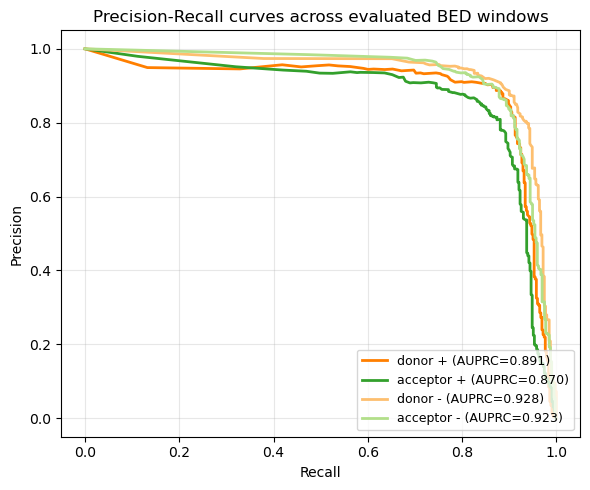

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

for cls_idx in range(len(SPLICE_CLASS_NAMES)):
    binary = (all_true_classes == cls_idx).astype(int)
    if binary.sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(binary, all_probs[:, cls_idx])
    auprc = average_precision_score(binary, all_probs[:, cls_idx])
    ax.plot(rec, prec, color=CLASS_COLORS[cls_idx], lw=2,
            label=f"{CLASS_LABELS[cls_idx]} (AUPRC={auprc:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Precision-Recall curves across evaluated BED windows")
plt.tight_layout()
plt.savefig("auprc.png", dpi=300)
plt.show()

### Usage alpha

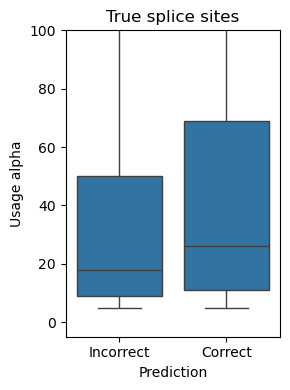

In [9]:
if all_alphas:
    import seaborn as sns
    alpha_df = pd.DataFrame(all_alphas).dropna(subset=["alpha"])
    # Only keep sites where the true label is not background
    if len(all_true_classes) == len(alpha_df):
        mask = all_true_classes != BACKGROUND_CLASS
        alpha_df = alpha_df[mask]
    fig, ax = plt.subplots(figsize=(3, 4))
    sns.boxplot(x="correct", y="alpha", data=alpha_df, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_ylim(-5, 100)
    ax.set_xticklabels(["Incorrect", "Correct"])
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Usage alpha")
    ax.set_title("True splice sites")
    plt.tight_layout()
    plt.savefig("alpha.png", dpi=300)
    plt.show()
else:
    print("No usage alpha data collected (check usage_file path or column names)")

## Splice usage correlation

Usage predictions were already computed by `collect_predictions()`. We now aggregate
and visualize the predicted vs observed usage correlation across all conditions.

**Comprehensive evaluation approach:**

- **Sites evaluated**: All unique (chromosome, position) pairs in usage.parquet within the evaluation windows
- **Conditions per site**: ALL conditions (all 86 for human, 93 for mouse)
- **Ground truth**: 
  - Observed conditions: Actual SSE values from usage.parquet
  - Unobserved conditions: 0 (assumption: site not used in that condition)
- **Mask**: True for all site-condition pairs

This comprehensive evaluation tests whether the model can distinguish between used (high SSE) and unused (low/zero SSE) conditions.

In [10]:
from scipy.stats import pearsonr, spearmanr

if not usage_per_cond:
    print("No usage predictions available (no usage head found or no usage data).")
else:
    n_conditions = len(usage_per_cond)
    
    # Aggregate all predictions across conditions
    records = []
    for cond_idx, data in usage_per_cond.items():
        if len(data["pred"]) > 1:
            records.extend([
                {"pred_usage": p, "obs_sse": t, "condition": cond_idx}
                for p, t in zip(data["pred"], data["true"])
            ])
    
    usage_corr_df = pd.DataFrame(records)
    print(f"\nCollected {len(usage_corr_df)} site-condition pairs across {n_conditions} conditions")
    
    if len(usage_corr_df) > 1:
        r_p, _ = pearsonr(usage_corr_df["obs_sse"], usage_corr_df["pred_usage"])
        r_s, _ = spearmanr(usage_corr_df["obs_sse"], usage_corr_df["pred_usage"])
        print(f"Overall  — Pearson r={r_p:.3f}  Spearman r={r_s:.3f}")
        
        # Per-condition summary (show first 5)
        print(f"\nPer-condition correlations:")
        for cond_idx, data in sorted(usage_per_cond.items())[:5]:
            if len(data["pred"]) > 1:
                r, _ = pearsonr(data["true"], data["pred"])
                print(f"  Condition {cond_idx:3d}: n={len(data['pred']):>6}  Pearson r={r:.3f}")
        if n_conditions > 5:
            print(f"  ... ({n_conditions - 5} more conditions)")
    else:
        print("Insufficient usage data for correlation analysis")



Collected 303273 site-condition pairs across 93 conditions
Overall  — Pearson r=0.650  Spearman r=0.590

Per-condition correlations:
  Condition   0: n=  3261  Pearson r=0.718
  Condition   1: n=  3261  Pearson r=0.813
  Condition   2: n=  3261  Pearson r=0.764
  Condition   3: n=  3261  Pearson r=0.664
  Condition   4: n=  3261  Pearson r=0.751
  ... (88 more conditions)


In [11]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Load usage.json to get condition name -> index mapping
usage_json_path = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/{species}/usage.json"
with open(usage_json_path, 'r') as f:
    usage_metadata = json.load(f)

condition_labels = usage_metadata.get("condition_labels", {})
print(f"Loaded {len(condition_labels)} conditions from {usage_json_path}")

# Parse tissue and timepoint from condition names
# e.g., "Brain_1" -> tissue="Brain", timepoint=1
condition_info = {}
for cond_name, cond_idx in condition_labels.items():
    parts = cond_name.rsplit('_', 1)  # Split from the right to handle names like "Kidney_1"
    if len(parts) == 2:
        tissue = parts[0]
        try:
            timepoint = int(parts[1])
            condition_info[cond_idx] = {
                'name': cond_name,
                'tissue': tissue,
                'timepoint': timepoint
            }
        except ValueError:
            # If the last part is not an integer, skip
            print(f"Warning: Could not parse timepoint from {cond_name}")
    else:
        print(f"Warning: Unexpected format for condition name: {cond_name}")

print(f"Successfully parsed {len(condition_info)} conditions")

# Compute per-condition correlations
condition_correlations = []
if usage_per_cond:
    for cond_idx, data in usage_per_cond.items():
        if len(data["pred"]) > 1:  # Need at least 2 points for correlation
            r, p_value = pearsonr(data["true"], data["pred"])
            if cond_idx in condition_info:
                condition_correlations.append({
                    'condition_idx': cond_idx,
                    'condition_name': condition_info[cond_idx]['name'],
                    'tissue': condition_info[cond_idx]['tissue'],
                    'timepoint': condition_info[cond_idx]['timepoint'],
                    'correlation': r,
                    'p_value': p_value,
                    'n_sites': len(data["pred"])
                })
else:
    print("No usage predictions available (usage_per_cond is empty)")

corr_df = pd.DataFrame(condition_correlations)
print(f"\nComputed correlations for {len(corr_df)} conditions")
if len(corr_df) > 0:
    print(f"Tissues: {sorted(corr_df['tissue'].unique())}")
    display(corr_df.head(10))

Loaded 86 conditions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.json
Successfully parsed 86 conditions

Computed correlations for 86 conditions
Tissues: ['Brain', 'Cerebellum', 'Heart', 'Kidney', 'Liver', 'Midbrain', 'Ovary', 'Testis']


/tmp/ipykernel_3527611/1518247333.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p_value = pearsonr(data["true"], data["pred"])


,condition_idx,condition_name,tissue,timepoint,correlation,p_value,n_sites
0,0,Brain_1,Brain,1,0.717722,0.000000e+00,3261
1,1,Brain_10,Brain,10,0.813416,0.000000e+00,3261
2,2,Brain_11,Brain,11,0.763603,0.000000e+00,3261
3,3,Brain_12,Brain,12,0.663916,0.000000e+00,3261
4,4,Brain_13,Brain,13,0.751164,0.000000e+00,3261
5,5,Brain_14,Brain,14,0.731817,0.000000e+00,3261
6,6,Brain_15,Brain,15,0.450787,5.386840e-163,3261
7,7,Brain_2,Brain,2,0.753239,0.000000e+00,3261
8,8,Brain_3,Brain,3,0.729235,0.000000e+00,3261
9,9,Brain_4,Brain,4,0.771446,0.000000e+00,3261


Plot correlations per tissue

/tmp/ipykernel_3527611/3541827289.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


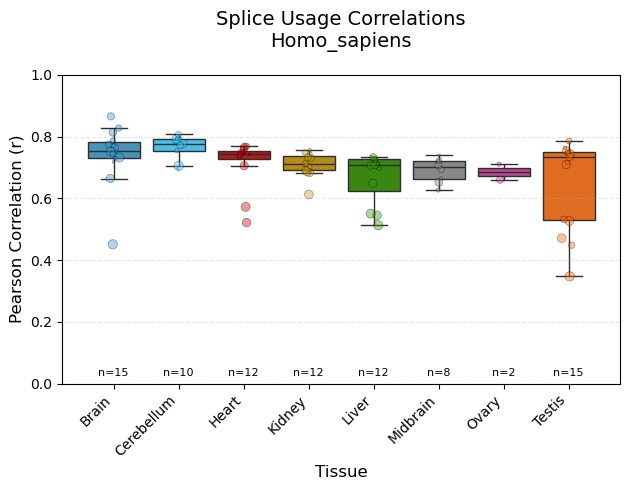


Summary by tissue


,N,Mean r,Median r,Std r,Min r,Max r
tissue,,,,,,
Cerebellum,9,0.764,0.777,0.039,0.695,0.807
Brain,15,0.743,0.753,0.094,0.451,0.865
Heart,12,0.713,0.745,0.080,0.522,0.768
Testis,15,0.652,0.734,0.144,0.347,0.785
Kidney,12,0.709,0.711,0.039,0.612,0.756
Liver,12,0.667,0.707,0.083,0.513,0.735
Midbrain,8,0.690,0.700,0.039,0.626,0.740
Ovary,2,0.685,0.685,0.036,0.660,0.711


In [12]:
if len(corr_df) == 0:
    print("No correlation data available for plotting")
else:
    # Sort tissues alphabetically for consistent ordering
    tissues = sorted(corr_df['tissue'].unique())
    n_tissues = len(tissues)
    
    # Create figure with appropriate size
    fig, ax = plt.subplots(figsize=(max(6, n_tissues * 0.8), 5))
    
    # Create boxplot (with lower zorder so points appear on top)
    sns.boxplot(
        data=corr_df,
        x='tissue',
        y='correlation',
        order=tissues,
        showfliers=False,
        palette=[TISSUE_COLORS.get(t, '#888888') for t in tissues],
        ax=ax,
        zorder=1
    )
    
    # Add individual points with size scaled to timepoint and colored by tissue
    # Plot manually using scatter to control point sizes and colors
    # Use higher zorder to ensure points are drawn on top of boxplots
    for i, tissue in enumerate(tissues):
        tissue_data = corr_df[corr_df['tissue'] == tissue]
        # Add small random jitter to x positions
        x_positions = np.random.normal(i, 0.04, size=len(tissue_data))
        # Scale point sizes based on timepoint (multiply by factor for visibility)
        point_sizes = tissue_data['timepoint'].values * 3
        # Get tissue color
        tissue_color = TISSUE_COLORS.get(tissue, '#888888')
        ax.scatter(
            x_positions,
            tissue_data['correlation'].values,
            s=point_sizes,
            color=tissue_color,
            alpha=0.4,
            edgecolors='black',
            linewidths=0.5,
            zorder=3
        )
    
    # Customize plot
    ax.set_ylim(0, 1)
    ax.set_xlabel('Tissue', fontsize=12)
    ax.set_ylabel('Pearson Correlation (r)', fontsize=12)
    ax.set_title(f'Splice Usage Correlations\n{species}', fontsize=14, pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    
    # Rotate x-axis labels if needed
    plt.xticks(rotation=45, ha='right')
    
    # Add sample size annotations
    for i, tissue in enumerate(tissues):
        n = len(corr_df[corr_df['tissue'] == tissue])
        median_r = corr_df[corr_df['tissue'] == tissue]['correlation'].median()
        ax.text(i, ax.get_ylim()[1] * 0.05, f'n={n}', ha='center', va='top', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('usage_correlation_by_tissue.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("Summary by tissue")
    print("="*80)
    summary = corr_df.groupby('tissue')['correlation'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    summary.columns = ['N', 'Mean r', 'Median r', 'Std r', 'Min r', 'Max r']
    summary = summary.sort_values('Median r', ascending=False)
    display(summary.round(3))

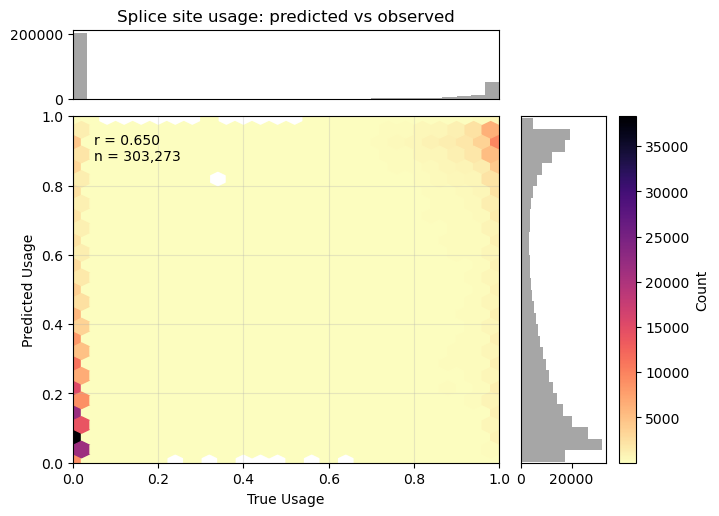

In [13]:
import matplotlib.pyplot as plt

if not usage_per_cond or "usage_corr_df" not in dir() or len(usage_corr_df) == 0:
    print("No usage correlation data available — check if usage head was loaded.")
else:
    true_all = usage_corr_df["obs_sse"].to_numpy(dtype="float32")
    pred_all = usage_corr_df["pred_usage"].to_numpy(dtype="float32")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    hb = ax.hexbin(true_all, pred_all, gridsize=25, cmap="magma_r", mincnt=1)

    num_points = len(true_all)
    if true_all.std() > 1e-8 and pred_all.std() > 1e-8:
        corr = float(np.corrcoef(true_all, pred_all)[0, 1])
        ax.text(0.05, 0.95, f"r = {corr:.3f}\nn = {num_points:,}",
                transform=ax.transAxes, fontsize=10, verticalalignment="top")

    # Marginal histograms
    ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
    ax_histx.hist(true_all, bins=30, color="gray", alpha=0.7)
    ax_histx.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)
    ax_histy.hist(pred_all, bins=30, orientation="horizontal", color="gray", alpha=0.7)
    ax_histy.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)

    cax = ax.inset_axes([1.28, 0, 0.04, 1])
    fig.colorbar(hb, cax=cax, label="Count")

    ax.set_xlabel("True Usage")
    ax.set_ylabel("Predicted Usage")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Splice site usage: predicted vs observed")
    ax.grid(True, alpha=0.3)

    plt.savefig("usage_scatter.png", dpi=300, bbox_inches="tight")
